# How often is a satellite overhead?

The [live tracker](https://shaunak3000.github.io/satellite-tracker/) shows what's
above your horizon *right now*. This notebook answers the statistical version of
that question: **how many satellites are overhead at any instant, and how does that
depend on where you live?**

Method: take the full active-satellite catalog (`tles.json`, ~15,900 objects,
refreshed daily from CelesTrak by this repo's CI), propagate every orbit with SGP4
over a full day at 60-second resolution, and count what's above a 10° elevation
mask for observers placed every 5° of latitude. One day of simulated time is enough:
LEO orbits precess across all longitudes while Earth rotates underneath, so a 24 h
average is a good estimate of the long-run mean.

Everything runs from the repo's own data file — no API calls, no keys.

In [1]:
import json
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sgp4.api import Satrec, SatrecArray, jday

# Chart chrome: dark surface + ink roles, matching the tracker's UI
SURFACE = "#1a1a19"
INK, INK2, MUTED = "#ffffff", "#c3c2b7", "#898781"
GRID, BASELINE = "#2c2c2a", "#383835"
# Validated categorical palette (dark mode, all-pairs CVD >= 10.3 with
# secondary encoding: direct labels on lines, marker shapes on the scatter)
C_BLUE, C_YELLOW, C_GREEN, C_MAGENTA, C_RED = (
    "#3987e5", "#c98500", "#008300", "#d55181", "#e66767")

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "figure.dpi": 110, "savefig.dpi": 165,
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "DejaVu Sans"],
    "text.color": INK2, "axes.labelcolor": INK2,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": BASELINE, "axes.linewidth": 1.0,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlecolor": INK, "axes.titlesize": 13, "axes.titleweight": "bold",
    "legend.frameon": False, "legend.labelcolor": INK2,
})

## The catalog

In [2]:
with open("../tles.json") as f:
    data = json.load(f)

tles = [t for t in data["tles"] if t.get("line1") and t.get("line2")]
fetched = datetime.fromisoformat(data["fetched_at"].replace("Z", "+00:00"))
print(f"{len(tles):,} satellites, fetched {fetched:%Y-%m-%d %H:%M} UTC")

cat_of = np.array([t.get("category", "Other") for t in tles])
names = np.array([t["name"] for t in tles])
norads = np.array([t.get("norad", 0) for t in tles])
pd.Series(cat_of).value_counts().rename("satellites").to_frame()

15,914 satellites, fetched 2026-07-05 08:38 UTC


,satellites
Starlink,10703
Other,4962
GPS,155
Military,52
Weather,34
ISS,8


## Propagating 15,900 orbits for a day

`sgp4`'s vectorized `SatrecArray` propagates the whole catalog at once. Positions
come back in the TEME inertial frame; rotating by Greenwich Mean Sidereal Time
gives Earth-fixed (ECEF) coordinates, from which elevation above each observer's
horizon is a dot product with the local vertical. Observers sit at sea level every
5° of latitude along the 93.09°W meridian (the tracker's default longitude —
for LEO the longitude choice washes out over a day; for the geostationary belt
it matters, which is its own finding below).

In [3]:
STEP_S = 60
N_T = 24 * 3600 // STEP_S + 1
MIN_EL_DEG = 10.0

jd0, fr0 = jday(fetched.year, fetched.month, fetched.day,
                fetched.hour, fetched.minute, fetched.second)
jd_arr = np.full(N_T, jd0)
fr_arr = fr0 + np.arange(N_T) * STEP_S / 86400.0


def gmst_rad(jd):
    t = (jd - 2451545.0) / 36525.0
    sec = (67310.54841 + (876600.0 * 3600 + 8640184.812866) * t
           + 0.093104 * t**2 - 6.2e-6 * t**3)
    return np.deg2rad((sec % 86400.0) / 240.0)


LATS = np.arange(0, 90, 5)
LON = np.deg2rad(-93.09)
A_KM, F = 6378.137, 1 / 298.257223563
E2 = F * (2 - F)

phi = np.deg2rad(LATS)
n_phi = A_KM / np.sqrt(1 - E2 * np.sin(phi) ** 2)
obs_ecef = np.stack([n_phi * np.cos(phi) * np.cos(LON),
                     n_phi * np.cos(phi) * np.sin(LON),
                     n_phi * (1 - E2) * np.sin(phi)], axis=1)
up = np.stack([np.cos(phi) * np.cos(LON),
               np.cos(phi) * np.sin(LON),
               np.sin(phi)], axis=1)

g = gmst_rad(jd_arr + fr_arr)
cosg, sing = np.cos(g), np.sin(g)

CATS = ["Starlink", "Other", "GPS", "Weather", "Military"]
counts = np.zeros((len(CATS), len(LATS), N_T))

# Named satellites whose elevation series we keep in full (found below)
sats = [Satrec.twoline2rv(t["line1"], t["line2"]) for t in tles]
incl = np.array([np.rad2deg(s.inclo) for s in sats])
period_min = np.array([2 * np.pi / s.no_kozai for s in sats])


def find(mask, label):
    idx = np.flatnonzero(mask)
    if len(idx) == 0:
        raise LookupError(label)
    return int(idx[0])


def sub_lon_deg(i):
    _, r, _ = sats[i].sgp4(jd0, fr0)
    x, y = r[0], r[1]
    g0 = gmst_rad(np.array([jd0 + fr0]))[0]
    return np.degrees(np.arctan2(-np.sin(g0) * x + np.cos(g0) * y,
                                 np.cos(g0) * x + np.sin(g0) * y))


i_iss = find(norads == 25544, "ISS")
i_stl = find((cat_of == "Starlink") & (np.abs(incl - 53) < 1), "Starlink 53°")
i_noaa = find(np.char.startswith(names, "NOAA 2"), "NOAA")
i_gps = find(np.char.startswith(names, "NAVSTAR"), "NAVSTAR")
# GEO pick: the GOES nearest our meridian. (GOES 14, the in-orbit spare, has
# drifted to ~131°E — from 93°W it literally never rises. Position matters.)
geo_belt = (np.abs(period_min - 1436) < 10) & (incl < 3)
goes = np.flatnonzero(geo_belt & np.char.startswith(names, "GOES"))
i_geo = int(min(goes, key=lambda i: abs(sub_lon_deg(i) - np.degrees(LON))))
named_idx = [i_iss, i_stl, i_noaa, i_gps, i_geo]
named_el = np.zeros((len(named_idx), len(LATS), N_T))
print("Named satellites:", ", ".join(names[i] for i in named_idx))

CHUNK = 2000
for lo in range(0, len(sats), CHUNK):
    hi = min(lo + CHUNK, len(sats))
    err, r, _ = SatrecArray(sats[lo:hi]).sgp4(jd_arr, fr_arr)
    r[err != 0] = np.nan
    x, y, z = r[..., 0], r[..., 1], r[..., 2]
    ecef = np.stack([cosg * x + sing * y, -sing * x + cosg * y, z], axis=-1)
    for j in range(len(LATS)):
        rho = ecef - obs_ecef[j]
        el = np.degrees(np.arcsin(
            np.einsum("stk,k->st", rho, up[j])
            / np.linalg.norm(rho, axis=-1)))
        vis = np.nan_to_num(el, nan=-90.0) > MIN_EL_DEG
        for c, cat in enumerate(CATS):
            counts[c, j] += vis[cat_of[lo:hi] == cat].sum(axis=0)
        for k, gi in enumerate(named_idx):
            if lo <= gi < hi:
                named_el[k, j] = np.nan_to_num(el[gi - lo], nan=-90.0)

mean_overhead = counts.mean(axis=2)

Named satellites: ISS (ZARYA), STARLINK-1008, NOAA 20 (JPSS-1), NAVSTAR 43 (USA 132), GOES 17


## 1. How many satellites are above you at any instant?

The mean count above 10° elevation, by category, as a function of observer
latitude. Note the log scale — the spread covers two orders of magnitude.

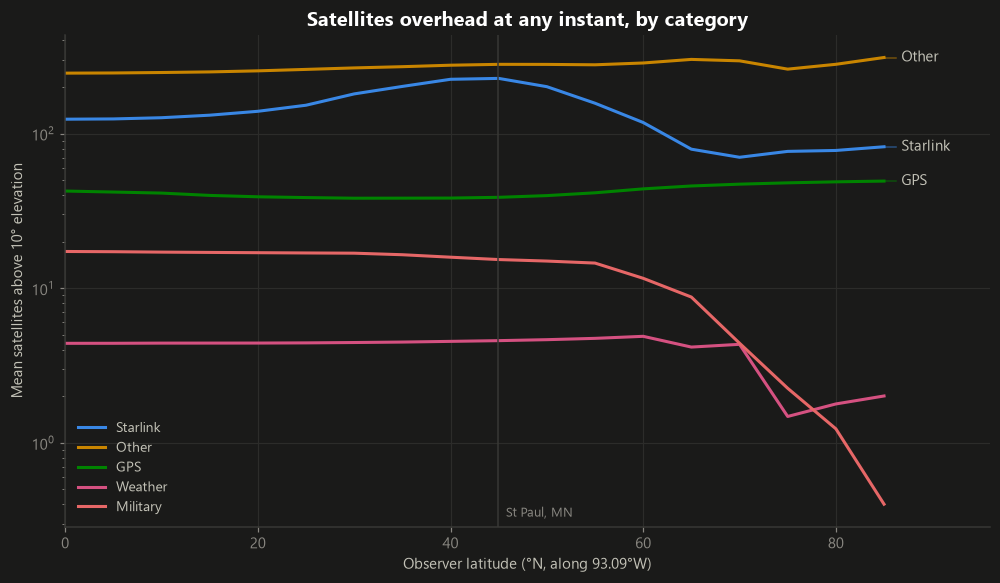

In [4]:
ST_PAUL = 44.95


def label_ends(ax, xs, series, pad=1.0):
    order = sorted(range(len(series)), key=lambda i: -series[i][1][-1])
    y_prev = None
    for i in order:
        lbl, ys, color = series[i]
        y = ys[-1]
        if y_prev is not None and ax.get_yscale() == "log":
            y = min(y, y_prev / 1.35)
        y_prev = y
        ax.annotate(lbl, (xs[-1] + pad, y), color=INK2, fontsize=9.5,
                    va="center", annotation_clip=False)
        ax.plot([xs[-1], xs[-1] + pad * 0.7], [ys[-1], y],
                color=color, lw=1, alpha=0.5, clip_on=False)


cat_colors = dict(zip(CATS, [C_BLUE, C_YELLOW, C_GREEN, C_MAGENTA, C_RED]))

fig, ax = plt.subplots(figsize=(9.2, 5.4))
series = []
for cat in CATS:
    ys = np.clip(mean_overhead[CATS.index(cat)], 0.05, None)
    ax.plot(LATS, ys, color=cat_colors[cat], lw=2)
    if cat in ("Other", "Starlink", "GPS"):
        series.append((cat, ys, cat_colors[cat]))
ax.set_yscale("log")
ax.axvline(ST_PAUL, color=BASELINE, lw=1)
ax.text(ST_PAUL + 0.8, 0.02, "St Paul, MN", color=MUTED, fontsize=8.5,
        transform=ax.get_xaxis_transform())
label_ends(ax, LATS, series, pad=1.8)
ax.legend(handles=[Line2D([], [], color=cat_colors[c], lw=2, label=c)
                   for c in CATS], loc="lower left", fontsize=9)
ax.set_xlabel("Observer latitude (°N, along 93.09°W)")
ax.set_ylabel("Mean satellites above 10° elevation")
ax.set_title("Satellites overhead at any instant, by category")
ax.set_xlim(0, 96)
fig.tight_layout()
fig.savefig("../docs/overhead_by_latitude.png", bbox_inches="tight")
plt.show()

In [5]:
tbl = pd.DataFrame(mean_overhead.round(1), index=CATS,
                   columns=[f"{la}°" for la in LATS])
tbl[["0°", "25°", "45°", "65°", "85°"]]

,0°,25°,45°,65°,85°
Starlink,123.8,152.5,227.4,79.2,82.2
Other,245.9,259.9,280.3,301.6,310.3
GPS,42.5,38.6,38.7,45.8,49.3
Weather,4.4,4.4,4.6,4.2,2.0
Military,17.3,16.9,15.3,8.8,0.4


Three things worth seeing here:

- **"Other" beats Starlink at every latitude** even though Starlink is 67% of the
  catalog. Most of "Other" lives in higher orbits (MEO, GEO, graveyard) that stay
  above the horizon for hours, while a 550 km Starlink races across the sky in
  minutes — population and *presence* are different things.
- **Starlink coverage peaks near 50–55° latitude** — the density edge of its main
  53°-inclination shells — then collapses toward the poles, propped up only by its
  small polar shells.
- **Navigation is engineered flat.** The tracker's "GPS" category is the GNSS
  umbrella — GPS, GLONASS, Galileo, BeiDou — and together they hold a near-constant
  ~40 satellites above 10° from the equator to the poles. Flatness is the design
  spec: each constellation alone must give any point on Earth the ≥ 4 satellites a
  position fix needs.

## 2. Same question for individual satellites

Category totals hide the mechanics: an individual satellite's visibility is set by
its altitude and inclination. Five familiar satellites, same experiment —
**fraction of the day above 10°** and **number of distinct passes per day**.

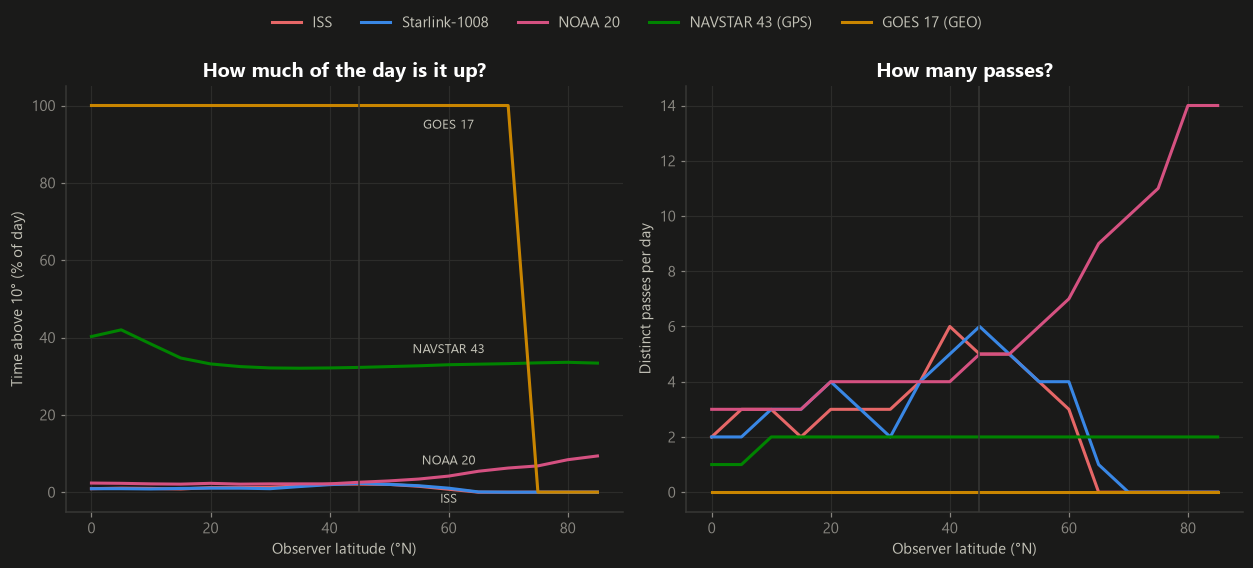

In [6]:
named_labels = ["ISS", names[i_stl].title(), names[i_noaa].split(" (")[0],
                names[i_gps].split(" (")[0] + " (GPS)", names[i_geo] + " (GEO)"]
named_colors = [C_RED, C_BLUE, C_MAGENTA, C_GREEN, C_YELLOW]

vis_named = named_el > MIN_EL_DEG
frac = vis_named.mean(axis=2) * 100
passes = np.maximum(np.diff(vis_named.astype(np.int8), axis=2), 0).sum(axis=2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.8), sharex=True)
for k, (lbl, col) in enumerate(zip(named_labels, named_colors)):
    ax1.plot(LATS, frac[k], color=col, lw=2)
    ax2.plot(LATS, passes[k], color=col, lw=2)
ax1.set_ylabel("Time above 10° (% of day)")
ax2.set_ylabel("Distinct passes per day")
for ax in (ax1, ax2):
    ax.set_xlabel("Observer latitude (°N)")
    ax.axvline(ST_PAUL, color=BASELINE, lw=1)
ax1.set_title("How much of the day is it up?")
ax2.set_title("How many passes?")
for k, dy in [(4, -6), (3, 3), (2, 3), (0, -3.5)]:
    ax1.annotate(named_labels[k].split(" (")[0], (LATS[-6], frac[k, -6] + dy),
                 color=INK2, fontsize=8.5, ha="center")
fig.legend(handles=[Line2D([], [], color=c, lw=2, label=l)
                    for l, c in zip(named_labels, named_colors)],
           loc="upper center", bbox_to_anchor=(0.5, 1.08), ncol=5, fontsize=9.5)
fig.tight_layout()
fig.savefig("../docs/passes_by_latitude.png", bbox_inches="tight")
plt.show()

In [7]:
j45 = list(LATS).index(45)
pd.DataFrame({"satellite": named_labels,
              "inclination °": [round(float(incl[i]), 1) for i in named_idx],
              "period (min)": [round(float(period_min[i])) for i in named_idx],
              "% of day visible @45°N": frac[:, j45].round(1),
              "passes/day @45°N": passes[:, j45]})

,satellite,inclination °,period (min),% of day visible @45°N,passes/day @45°N
0,ISS,51.6,93,2.1,5
1,Starlink-1008,53.2,93,2.3,6
2,NOAA 20,98.8,101,2.6,5
3,NAVSTAR 43 (GPS),56.0,718,32.3,2
4,GOES 17 (GEO),1.0,1436,100.0,0


The inclination story, satellite by satellite:

- **ISS (51.6°)** is visible most often from latitudes just under its inclination —
  the orbit's ground track lingers at its turning latitude — and never rises above
  10° for observers past ~65°N.
- **A 53° Starlink** behaves like the ISS with a slightly higher ceiling; this is
  why Starlink service was mid-latitudes-first.
- **NOAA 20 (sun-synchronous, ~98.7°)** trades mid-latitude time for polar
  dominance: at 85°N it's overhead in many short passes a day —
  the standard polar-orbiter bargain.
- **NAVSTAR (GPS, 55° but at 20,200 km)** shows what altitude buys: similar
  inclination to Starlink, yet visible a third of the day *everywhere* with only
  a couple of long, slow passes.
- **GOES (geostationary)** is the degenerate case: parked over one longitude, it's
  simply *always up* (100%, zero "passes") until Earth's curvature hides it at
  high latitudes — why high-Arctic weather coverage needs Molniya/Tundra orbits
  instead. (The pick is position-aware: GOES 14, the in-orbit spare, has drifted
  to ~131°E and never rises over Minnesota at all.)

## 3. The population map

Every satellite in the catalog, placed by mean altitude and inclination. The
clusters are orbital *regimes* — each one a different engineering answer to
"where do you want to be over Earth?"

15,914 of 15,914 satellites have SATCAT orbit data


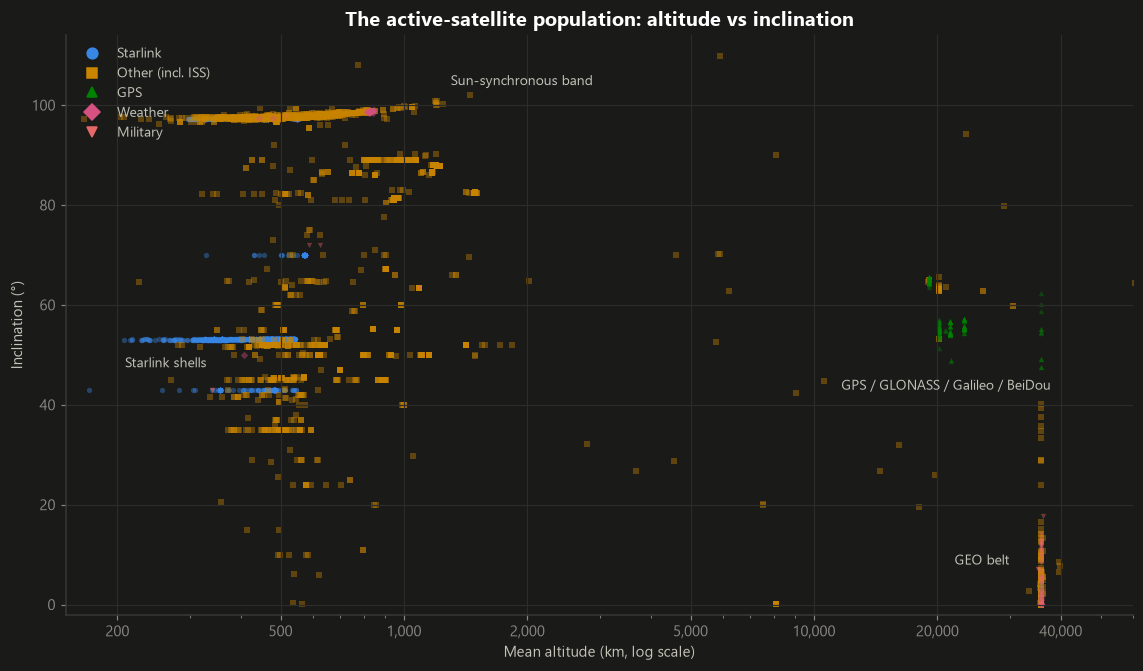

In [8]:
alt = np.array([(t.get("perigeeKm", np.nan) + t.get("apogeeKm", np.nan)) / 2
                if t.get("perigeeKm") and t.get("apogeeKm") else np.nan
                for t in tles])
ok = ~np.isnan(alt)
print(f"{ok.sum():,} of {len(tles):,} satellites have SATCAT orbit data")

fig, ax = plt.subplots(figsize=(10.5, 6.2))
markers = {"Starlink": "o", "Other": "s", "GPS": "^", "Weather": "D",
           "Military": "v"}
for cat in CATS:
    m = ok & ((cat_of == cat) if cat != "Other"
              else np.isin(cat_of, ["Other", "ISS"]))
    ax.scatter(alt[m], incl[m], s=12, marker=markers[cat],
               color=cat_colors[cat], alpha=0.4, linewidths=0)
ax.set_xscale("log")
ax.set_xlim(150, 60000)
ax.set_ylim(-2, 114)
ax.set_xticks([200, 500, 1000, 2000, 5000, 10000, 20000, 40000])
ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.set_xlabel("Mean altitude (km, log scale)")
ax.set_ylabel("Inclination (°)")
ax.set_title("The active-satellite population: altitude vs inclination")
ann = [("Starlink shells", 330, 47.5, "right"),
       ("Sun-synchronous band", 1300, 104, "left"),
       ("GPS / GLONASS / Galileo / BeiDou", 21000, 43, "center"),
       ("GEO belt", 30000, 8, "right")]
for txt, x, y, ha in ann:
    ax.annotate(txt, (x, y), color=INK2, fontsize=9, ha=ha)
ax.legend(handles=[Line2D([], [], color=cat_colors[c], marker=markers[c],
                          ls="", ms=7, label=("Other (incl. ISS)" if c == "Other" else c))
                   for c in CATS],
          loc="upper left", fontsize=9)
fig.tight_layout()
fig.savefig("../docs/population_map.png", bbox_inches="tight")
plt.show()

## Limitations, honestly

- **Radio horizon, not visual.** "Overhead" means above 10° elevation — it does not
  mean you could *see* the satellite, which additionally requires the satellite in
  sunlight and your sky dark.
- **One meridian.** Observers sit along 93.09°W. Irrelevant for LEO averages,
  but GEO results would shift for observers near the Pacific gap in the belt.
- **One day, one epoch.** A 24 h SGP4 run from a single TLE epoch; fine for
  statistics, not for precise pass times weeks out.
- **10° mask.** Terrain and buildings usually block more; a 25° mask roughly
  halves every count here.

*Data: [CelesTrak](https://celestrak.org/) GP elements + SATCAT, via this repo's
daily CI fetch. Propagation: [python-sgp4](https://pypi.org/project/sgp4/).
Reproduce: `pip install -r requirements.txt && jupytext --to notebook --execute coverage.py`.*